In [1]:
import moose
import matplotlib.pyplot as plt
import numpy as np 

INFO:numexpr.utils:NumExpr defaulting to 12 threads.


In [2]:
# Create containers
container = moose.Neutral('/sim')
data = moose.Neutral('/sim/data')
model = moose.Neutral('/sim/model')

In [3]:
axon = moose.Compartment(f'{model.path}/axon')

In [4]:

# Create a Hodgkin-Huxley-type channel and connect it to the compartment
kchan = moose.HHChannel(f'{axon.path}/K')
moose.connect(kchan, 'channel', axon, 'channel')
moose.showmsg(kchan.path)

INCOMING:
  /sim[0]/model[0]/axon[0]/K[0] [parentMsg] <-- /sim[0]/model[0]/axon[0] [childOut]
  /sim[0]/model[0]/axon[0]/K[0] [process,reinit] <-- /clock[0] [process4,reinit4]

OUTGOING:
  /sim[0]/model[0]/axon[0]/K[0] [childOut] --> /sim[0]/model[0]/axon[0]/K[0]/gateX[0] [parentMsg]
  /sim[0]/model[0]/axon[0]/K[0] [childOut] --> /sim[0]/model[0]/axon[0]/K[0]/gateY[0] [parentMsg]
  /sim[0]/model[0]/axon[0]/K[0] [childOut] --> /sim[0]/model[0]/axon[0]/K[0]/gateZ[0] [parentMsg]
  /sim[0]/model[0]/axon[0]/K[0] [channelOut] --> /sim[0]/model[0]/axon[0] [handleChannel]



In [5]:

kchan.Ek = -12.0   # mV with respect to resting Vm
# Gbar is maximum conductance. 
# The voltage dependent conductance value is computed and 
# stored in the field Gk, which we record in a table below
kchan.Gbar = 36.0  # mS/cm^2

In [6]:
kchan.Xpower = 4

In [7]:

# moose.element(path) returns the existing element at the given path
gate = moose.element(f'{kchan.path}/gateX')
# gate.useInterpolation = True   # use a lookup table for alpha and beta
gate.alphaExpr = '0.01 * (10 - v) / (exp((10 - v) / 10) - 1)'
gate.betaExpr = '0.125 * exp(-v / 80)'
gate.divs = 150
gate.min = -30.0
gate.max = 120.0

In [8]:
###################################################
# Do not touch this code
###################################################
def create_voltage_clamp(modelpath, datapath, compartment):
    """Creates a voltage clamp object under `modelpath` and 
    a table under `datapath` to record the command voltage.
    
    Returns the `moose.PulseGen` that gives the command value 
    to the voltage clamp.
    """
    path = f'{modelpath}/elec'  # create a separate container for electronics
    
    if moose.exists(path):   # avoid duplicate connect
        print(f'{path}: Object already exists')
        vclamp = moose.VClamp(f'{path}/vclamp')
        command = moose.PulseGen(f'{path}/command')
        command_tab = moose.Table(f'{datapath}/command')
        return vclamp, command, command_tab
    elec = moose.Neutral(path)    
    vclamp = moose.VClamp(f'{path}/vclamp')
    # The voltage clamp's output is `currentOut` which will be 
    # injected into the compartment
    moose.connect(vclamp, 'currentOut', compartment, 'injectMsg')
    # The voltage clamp object senses the voltage of the compartment
    moose.connect(compartment, 'VmOut', vclamp, 'sensedIn')
    command = moose.PulseGen(f'{path}/command')

    # Connect the output of the command pulse to the command input of the voltage clamp circuit
    moose.connect(command, 'output', vclamp, 'commandIn')

    # Also setup a table to record the command voltage of the VClamp directly
    command_tab = moose.Table(f'{datapath}/command')
    moose.connect(command_tab, 'requestOut', command, 'getOutputValue')
    
    # compartment.dt is the integration time step for the compartment 
    # `tau` is the time constant of the RC filter in the circuit.
    # 5 times the integration timestep value is a good starting point for tau
    vclamp.tau = 5 * compartment.dt
    # `gain` is the proportional gain of the PID controller. `Cm/dt` is a good value
    vclamp.gain = compartment.Cm / compartment.dt

    # `ti` is the integral time of the PID controller, `dt` is a good value
    vclamp.ti = compartment.dt
    # `td` is the derivative time of the PID controller. We can set it to 0
    
    return vclamp, command, command_tab


def set_command_timecourse(command, base, delay, level):
    """Set up an existing pulse generator `command` to output `base` as initial value 
    and `level` after `delay` time"""
    command.baseLevel = base   
    command.firstDelay = delay   
    command.secondDelay = 1e9    # Never stop 
    command.firstWidth = 1e9     # Never stop
    command.firstLevel = level  

In [9]:

# Insert voltage clamp circuitry
vclamp, command, command_tab = create_voltage_clamp(model.path, data.path, axon)
# baseline is set to equilibrium potential
# delay is 10 ms, start the voltage change at this time
# command level is -60 mV, which is 10 mV above equilibrium potential
set_command_timecourse(command, 0.0, 10.0, 10.0)

In [10]:
axon.Em = 0    # Hodgkin and Huxley used resting voltage as 0
axon.initVm = 0
axon.Cm = 1
axon.Rm = 1 / 0.3   # G_leak is 0.3 mS/cm^2

In [11]:
gK_tab = moose.Table(f'{data.path}/gK')
moose.connect(gK_tab, 'requestOut', kchan, 'getGk')
im_tab = moose.Table(f'{data.path}/Im')
moose.connect(im_tab, 'requestOut', axon, 'getIm')

<moose.SingleMsg path=/Msgs[0]/singleMsg[6] id=5 dataIndex=6 fieldIndex=0>

In [12]:
runtime = 50
# `reinit` initialize the simulation 
moose.reinit()
# run the simulation for `runtime` duration
moose.start(runtime)

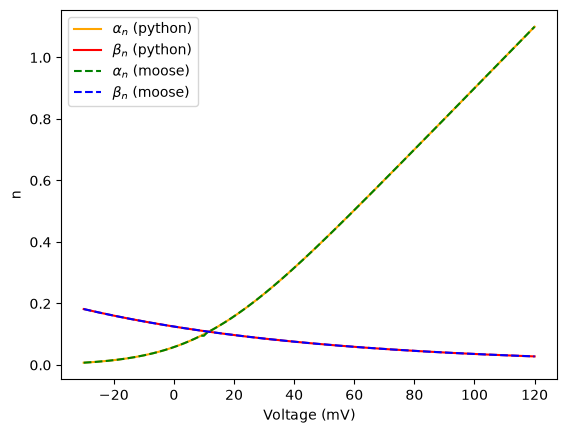

In [13]:

# Compute the values by HH formula
vdivs = 150
vmin = -30.0
vmax = 120.0
v = np.linspace(vmin, vmax, vdivs)
alpha_n = 0.01 * (10 - v) / (np.exp((10 - v)/10) - 1)
beta_n = 0.125 * np.exp(-v/80)

plt.plot(v, alpha_n, color='orange', label=r'$\alpha_{n}$ (python)')
plt.plot(v, beta_n, color='red', label=r'$\beta_{n}$ (python)')

#print(moose.showfields(gate))
alpha_moose = gate.tableA
beta_moose = gate.tableB - gate.tableA
v = np.linspace(gate.min, gate.max, len(alpha_moose))
plt.plot(v, alpha_moose, '--', color='green', label=r'$\alpha_{n}$ (moose)')
plt.plot(v, beta_moose,  '--', color='blue', label=r'$\beta_{n}$ (moose)')
plt.xlabel('Voltage (mV)')
plt.ylabel('n')
plt.legend()

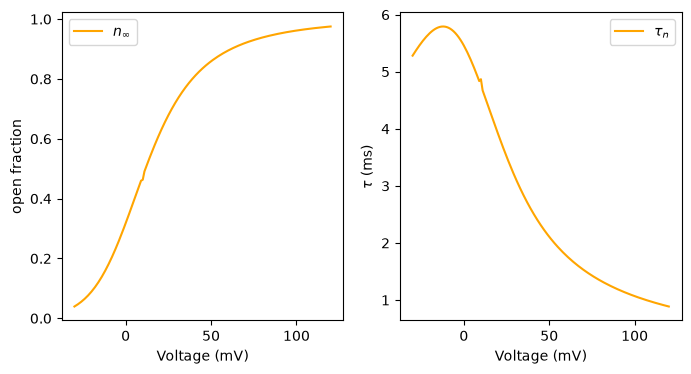

In [14]:
#print(moose.showfields(gate))
plt.subplot(121)
plt.plot(v, alpha_moose/gate.tableB, '-', color='orange', label=r'$n_{\infty}$')
plt.legend()
plt.xlabel('Voltage (mV)')
plt.ylabel('open fraction')

plt.subplot(122)
plt.plot(v, 1/gate.tableB,  '-', color='orange', label=r'$\tau_{n}$')
plt.legend()
plt.xlabel('Voltage (mV)')
plt.ylabel(r'$\tau$ (ms)')
plt.gcf().set_size_inches(8, 4)

Text(0.5, 0, 'Time (ms)')

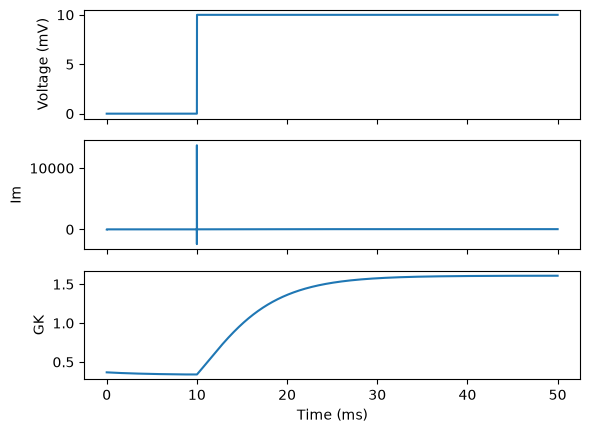

In [15]:
v_command = command_tab.vector
t_command = np.arange(len(v_command)) * command_tab.dt
fig, axes = plt.subplots(nrows=3, ncols=1, sharex='all')
axes[0].plot(t_command, v_command, label='Command voltage')
axes[0].set_ylabel('Voltage (mV)')

im = im_tab.vector
t_im = np.arange(len(im)) * im_tab.dt
axes[1].plot(t_im, im, label='Membrane current (mA/cm^2)')
axes[1].set_ylabel('Im')
#plt.plot(t_v, v_end, ':', label='Voltage at last compartment')
gK = gK_tab.vector
t_gK = np.arange(len(gK)) * gK_tab.dt
axes[2].plot(t_gK, gK)
axes[2].set_ylabel('GK')
axes[2].set_xlabel('Time (ms)')